<a href="https://colab.research.google.com/github/RTaylor89/ITAI_ML_MIDTERM_TEAM2/blob/main/03_Credit_Risk_Cleanup_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Risk Dataset Cleanup and Data Preparation

**Dataset:** Credit Risk Dataset (Kaggle)  
**Source page:** https://www.kaggle.com/datasets/laotse/credit-risk-dataset  
**Kaggle API URL used to obtain the file:** https://www.kaggle.com/api/v1/datasets/download/laotse/credit-risk-dataset

## Goal
The goal of this notebook is to clean and prepare the Credit Risk Dataset for a machine learning exercise.  
The target column is **`loan_status`**, so this project supports a **binary classification** problem.

## Important assignment rule
The dataset is split into **70% training** and **30% testing** first.  
**EDA and all preprocessing are performed only on the training data.**  
The testing dataset is saved in raw form and is **not touched**.

**Correction note:** this version caps `person_emp_length` at 100, ordinal-encodes `loan_grade`, and addresses skew in `person_income` and `loan_amnt` using log transforms.


In [1]:
# Run this cell only if your notebook environment is missing the required packages.
%pip install pandas numpy matplotlib scikit-learn ipython

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import pandas so we can work with the dataset as a DataFrame.
import pandas as pd

# Import numpy so we can work with missing values and safe math operations.
import numpy as np

# Import matplotlib so we can create simple charts for EDA.
import matplotlib.pyplot as plt

# Import display so tables render nicely in the notebook.
from IPython.display import display

# Import train_test_split so we can divide the data into training and testing sets.
from sklearn.model_selection import train_test_split

# 1. Load the raw dataset from the GitHub repo folder.
df = pd.read_csv("credit_risk_dataset.csv")

# 2. Show the first five rows of the untouched raw dataset.
display(df.head())

# 3. Print the raw dataset shape so we know how many rows and columns we started with.
print("Raw dataset shape:", df.shape)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Raw dataset shape: (32581, 12)


In [3]:
# 1. Split the raw dataset FIRST into training and testing sets.
# We stratify by loan_status so class balance stays similar in both splits.
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["loan_status"]
)

# 2. Reset the indexes so both DataFrames have clean row numbers.
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 3. Save the untouched raw training and testing splits for submission.
train_df.to_csv("05_Training_Split_Raw.csv", index=False)
test_df.to_csv("06_Testing_Split_Raw.csv", index=False)

# 4. Display the first five rows of the training data only.
display(train_df.head())

# 5. Print the shapes of the training and testing datasets.
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,26,62000,RENT,1.0,DEBTCONSOLIDATION,B,10000,11.26,0,0.16,N,2
1,23,39000,MORTGAGE,3.0,EDUCATION,C,5000,12.98,0,0.13,N,4
2,24,35000,RENT,1.0,DEBTCONSOLIDATION,A,12000,6.54,1,0.34,N,2
3,24,86000,RENT,1.0,HOMEIMPROVEMENT,B,12000,10.65,0,0.14,N,3
4,42,38400,RENT,4.0,MEDICAL,B,13000,NaN,1,0.34,N,11


Training shape: (22806, 12)
Testing shape: (9775, 12)


--- TRAINING DATA INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 22806 entries, 0 to 22805
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  22806 non-null  int64  
 1   person_income               22806 non-null  int64  
 2   person_home_ownership       22806 non-null  str    
 3   person_emp_length           22167 non-null  float64
 4   loan_intent                 22806 non-null  str    
 5   loan_grade                  22806 non-null  str    
 6   loan_amnt                   22806 non-null  int64  
 7   loan_int_rate               20606 non-null  float64
 8   loan_status                 22806 non-null  int64  
 9   loan_percent_income         22806 non-null  float64
 10  cb_person_default_on_file   22806 non-null  str    
 11  cb_person_cred_hist_length  22806 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.1 MB

--- TRAINING DATA 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,22806.000000,2.280600e+04,22806,22167.000000,22806,22806,22806.000000,20606.000000,22806.000000,22806.000000,22806,22806.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,11498,NaN,4520,7530,NaN,NaN,NaN,NaN,18758,NaN
mean,27.722880,6.620697e+04,NaN,4.796905,NaN,NaN,9598.740463,11.010418,0.218144,0.170173,NaN,5.797992
std,6.336638,6.387456e+04,NaN,4.120061,NaN,NaN,6313.133319,3.228057,0.412995,0.106759,NaN,4.056109
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.852475e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.963500e+04,NaN,7.000000,NaN,NaN,12250.000000,13.470000,0.000000,0.230000,NaN,8.000000



--- MISSING VALUES IN TRAINING DATA ---


loan_int_rate                 2200
person_emp_length              639
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


--- TARGET DISTRIBUTION ---


loan_status
0    0.781856
1    0.218144
Name: proportion, dtype: float64

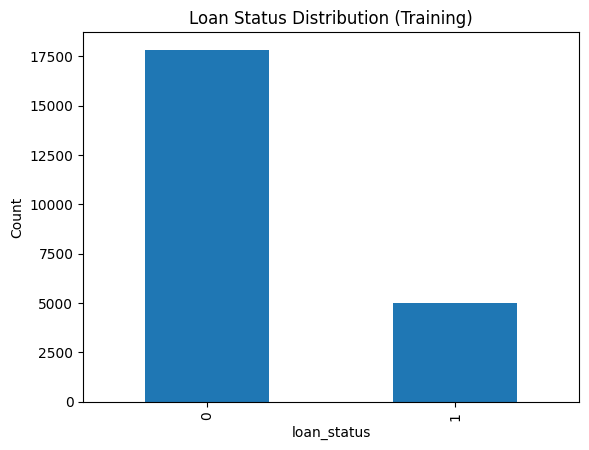

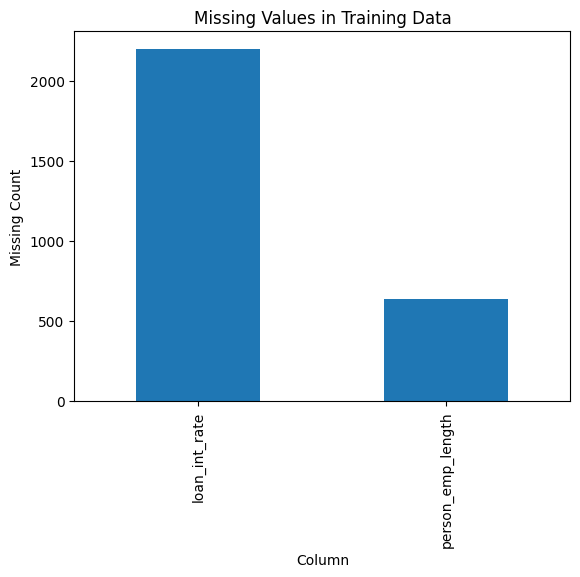

In [4]:
# -----------------------------
# EDA ON TRAINING DATA ONLY
# -----------------------------

# 1. Show general dataset information for the training data.
print("--- TRAINING DATA INFO ---")
train_df.info()

# 2. Show summary statistics for the training data.
print("\n--- TRAINING DATA SUMMARY STATISTICS ---")
display(train_df.describe(include="all"))

# 3. Count missing values in the training data.
print("\n--- MISSING VALUES IN TRAINING DATA ---")
missing_before = train_df.isnull().sum().sort_values(ascending=False)
display(missing_before)

# 4. Show the target distribution in the training data.
print("\n--- TARGET DISTRIBUTION ---")
display(train_df["loan_status"].value_counts(normalize=True))

# 5. Plot the target distribution.
train_df["loan_status"].value_counts().sort_index().plot(kind="bar", title="Loan Status Distribution (Training)")
plt.xlabel("loan_status")
plt.ylabel("Count")
plt.show()

# 6. Plot the missing values that are greater than zero.
missing_before[missing_before > 0].plot(kind="bar", title="Missing Values in Training Data")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.show()

In [5]:
# -----------------------------
# DATA CLEANING ON TRAINING DATA ONLY
# -----------------------------

# Make a copy so the original raw training split stays unchanged.
clean_train = train_df.copy()

# 1. Convert blank strings to real missing values in object columns.
object_columns = clean_train.select_dtypes(include="object").columns
clean_train[object_columns] = clean_train[object_columns].replace(r"^\s*$", np.nan, regex=True)

# 2. Handle unrealistic values in the training data only.
# Cap age to a reasonable range instead of letting obvious outliers distort the model.
clean_train["person_age"] = clean_train["person_age"].clip(lower=18, upper=100)

# Correction: cap person_emp_length at 100. Do not replace the 123 outlier by scaling it.
clean_train["person_emp_length"] = clean_train["person_emp_length"].clip(lower=0, upper=100)
clean_train["person_emp_length"] = clean_train["person_emp_length"].fillna(clean_train["person_emp_length"].median())

# 3. Fill missing interest rates using the median interest rate for each loan grade.
clean_train["loan_int_rate"] = clean_train.groupby("loan_grade")["loan_int_rate"].transform(
    lambda x: x.fillna(x.median())
)

# 4. Fill any remaining interest-rate values with the overall training median.
clean_train["loan_int_rate"] = clean_train["loan_int_rate"].fillna(clean_train["loan_int_rate"].median())

# 5. Create engineered features before log transforms so ratios stay meaningful.
raw_income = clean_train["person_income"].clip(lower=1)
raw_loan_amount = clean_train["loan_amnt"].clip(lower=0)
clean_train["debt_to_income_ratio"] = raw_loan_amount / raw_income
clean_train["income_per_credit_year"] = raw_income / (clean_train["cb_person_cred_hist_length"] + 1)
clean_train["credit_history_to_age_ratio"] = clean_train["cb_person_cred_hist_length"] / clean_train["person_age"]

# 6. Explicitly address skew for income and loan amount using log1p transforms.
clean_train["person_income"] = np.log1p(raw_income)
clean_train["loan_amnt"] = np.log1p(raw_loan_amount)

# 7. Replace infinite values from division with missing values, then fill them with medians.
clean_train = clean_train.replace([np.inf, -np.inf], np.nan)
for column in ["debt_to_income_ratio", "income_per_credit_year", "credit_history_to_age_ratio"]:
    clean_train[column] = clean_train[column].fillna(clean_train[column].median())

# 8. Show missing values and correction checks after cleaning.
print("Missing values AFTER cleaning:")
display(clean_train.isnull().sum())
print("Max person_emp_length after cap:", clean_train["person_emp_length"].max())
print("Skew after log transform - person_income:", round(clean_train["person_income"].skew(), 3))
print("Skew after log transform - loan_amnt:", round(clean_train["loan_amnt"].skew(), 3))

Missing values AFTER cleaning:


C:\Users\ryjel.SCC\AppData\Local\Temp\ipykernel_10036\2998984163.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = clean_train.select_dtypes(include="object").columns


person_age                     0
person_income                  0
person_home_ownership          0
person_emp_length              0
loan_intent                    0
loan_grade                     0
loan_amnt                      0
loan_int_rate                  0
loan_status                    0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
debt_to_income_ratio           0
income_per_credit_year         0
credit_history_to_age_ratio    0
dtype: int64

Max person_emp_length after cap: 100.0
Skew after log transform - person_income: 0.147
Skew after log transform - loan_amnt: -0.456


In [6]:
# -----------------------------
# ENCODING
# -----------------------------

# 1. Convert the default history flag from Y/N into 1/0.
clean_train["cb_person_default_on_file"] = clean_train["cb_person_default_on_file"].map({"Y": 1, "N": 0})

# 2. Correction: loan_grade is ordinal, so encode it as ranked values instead of one-hot columns.
# A is the strongest grade and G is the weakest grade.
grade_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
clean_train["loan_grade"] = clean_train["loan_grade"].map(grade_mapping)

# 3. One-hot encode only the nominal categorical columns.
clean_train = pd.get_dummies(
    clean_train,
    columns=["person_home_ownership", "loan_intent"],
    drop_first=False
)

# 4. Convert any True/False dummy columns into integers.
for column in clean_train.select_dtypes(include=["bool"]).columns:
    clean_train[column] = clean_train[column].astype(int)

# 5. Show the cleaned training dataset after preprocessing.
display(clean_train.head())

# 6. Print the final number of missing values to confirm cleanup is complete.
print("Remaining missing values in cleaned training data:", clean_train.isnull().sum().sum())
print("Loan grade encoded values:", sorted(clean_train["loan_grade"].unique()))

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,26,11.034906,1.0,2,9.210440,11.26,0,0.16,0,2,...,0,0,0,1,1,0,0,0,0,0
1,23,10.571343,3.0,3,8.517393,12.98,0,0.13,0,4,...,1,0,0,0,0,1,0,0,0,0
2,24,10.463132,1.0,1,9.392745,6.54,1,0.34,0,2,...,0,0,0,1,1,0,0,0,0,0
3,24,11.362114,1.0,2,9.392745,10.65,0,0.14,0,3,...,0,0,0,1,0,0,1,0,0,0
4,42,10.555839,4.0,2,9.472782,10.99,1,0.34,0,11,...,0,0,0,1,0,0,0,1,0,0


Remaining missing values in cleaned training data: 0
Loan grade encoded values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [7]:
# -----------------------------
# BEFORE / AFTER COMPARISON AND EXPORT
# -----------------------------

# 1. Show the training data before cleanup.
print("TRAINING DATA BEFORE CLEANUP")
display(train_df.head())

# 2. Show the training data after cleanup.
print("TRAINING DATA AFTER CLEANUP")
display(clean_train.head())

# 3. Print the number of columns before and after preprocessing.
print("Columns before preprocessing:", train_df.shape[1])
print("Columns after preprocessing:", clean_train.shape[1])

# 4. Save the cleaned training dataset.
clean_train.to_csv("07_Clean_Training_Dataset.csv", index=False)

# 5. Save the final clean dataset.
# In this assignment, the final clean dataset is the cleaned training dataset
# because the testing split must remain untouched.
clean_train.to_csv("08_Final_Clean_Dataset.csv", index=False)

# 6. Print the final output shapes.
print("Raw training dataset shape:", train_df.shape)
print("Untouched raw testing dataset shape:", test_df.shape)
print("Clean training dataset shape:", clean_train.shape)

TRAINING DATA BEFORE CLEANUP


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,26,62000,RENT,1.0,DEBTCONSOLIDATION,B,10000,11.26,0,0.16,N,2
1,23,39000,MORTGAGE,3.0,EDUCATION,C,5000,12.98,0,0.13,N,4
2,24,35000,RENT,1.0,DEBTCONSOLIDATION,A,12000,6.54,1,0.34,N,2
3,24,86000,RENT,1.0,HOMEIMPROVEMENT,B,12000,10.65,0,0.14,N,3
4,42,38400,RENT,4.0,MEDICAL,B,13000,NaN,1,0.34,N,11


TRAINING DATA AFTER CLEANUP


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,26,11.034906,1.0,2,9.210440,11.26,0,0.16,0,2,...,0,0,0,1,1,0,0,0,0,0
1,23,10.571343,3.0,3,8.517393,12.98,0,0.13,0,4,...,1,0,0,0,0,1,0,0,0,0
2,24,10.463132,1.0,1,9.392745,6.54,1,0.34,0,2,...,0,0,0,1,1,0,0,0,0,0
3,24,11.362114,1.0,2,9.392745,10.65,0,0.14,0,3,...,0,0,0,1,0,0,1,0,0,0
4,42,10.555839,4.0,2,9.472782,10.99,1,0.34,0,11,...,0,0,0,1,0,0,0,1,0,0


Columns before preprocessing: 12
Columns after preprocessing: 23
Raw training dataset shape: (22806, 12)
Untouched raw testing dataset shape: (9775, 12)
Clean training dataset shape: (22806, 23)


## How this dataset can be used for machine learning

This dataset supports a **supervised binary classification** problem because the target column is **`loan_status`**.

A future machine learning model can use borrower information, credit history, loan details, and engineered ratio features to predict whether a loan is likely to become risky or default.

Possible models include:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Useful evaluation metrics include:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

This is a strong machine learning exercise because the dataset includes missing values, categorical features, ordered categories, numeric scaling needs, and business-relevant feature engineering opportunities.
